In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [13]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/B_varreduction/pca_variables.csv")
weathercluster_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/weather_7.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")

GEV_clusters = GEV_clusters[~GEV_clusters["cluster"].isin([0, 5])].copy()
weathercluster_df = weathercluster_df[~weathercluster_df["cluster"].isin([0, 5])].copy()

stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

label_df = GEV_clusters[["station", "cluster", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on=["station","lat", "lon"], how="inner")

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac", "extract_time", "name")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Get sorted unique remaining clusters
unique_clusters = sorted(model_df["cluster"].unique())

# Build mapping → start numbering from 1
cluster_map = {old: new for new, old in enumerate(unique_clusters, start=1)}

# Apply remapping
model_df["cluster"] = model_df["cluster"].map(cluster_map)
weathercluster_df["cluster"] = weathercluster_df["cluster"].map(cluster_map)

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster']

In [14]:
drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac", "extract_time", "name", "Unnamed")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = weathercluster_df.drop(columns=[c for c in cols_to_drop if c in weathercluster_df.columns])
y = weathercluster_df['cluster']

In [15]:
df = X [X .columns.drop(list(X .filter(regex='name')))]
df["magnitude"] = stats_df["magnitude"]
weathercluster_df["magnitude"] = stats_df["magnitude"]

In [16]:
df.columns

Index(['wind_wave_alignment', 'tp', 'mwd', 'mwp', 'wind_dir', 'v10_abs',
       'tau_v', 'msl', 'sp', 'v10', 'u10_abs', 'swh', 'magnitude'],
      dtype='object')

Accuracy: 0.9861111111111112
              precision    recall  f1-score   support

           1       0.98      0.99      0.99      2535
           2       0.99      0.98      0.99      1379
           3       0.99      0.98      0.98      2554
           4       1.00      0.99      0.99       690
           5       0.98      0.99      0.98      3282

    accuracy                           0.99     10440
   macro avg       0.99      0.99      0.99     10440
weighted avg       0.99      0.99      0.99     10440



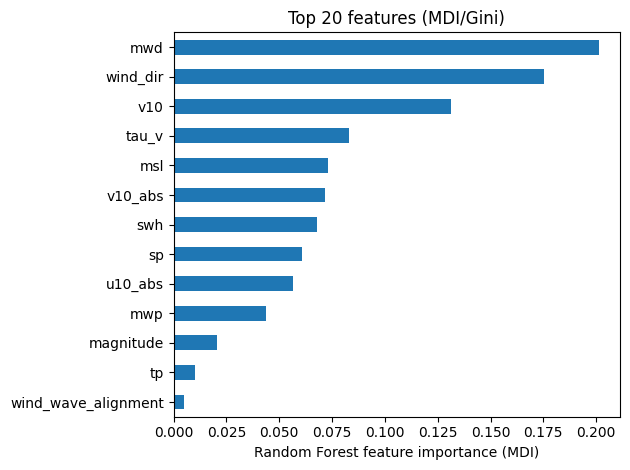


Top features (MDI):
mwd                    0.201232
wind_dir               0.175407
v10                    0.131154
tau_v                  0.082950
msl                    0.073156
v10_abs                0.071448
swh                    0.068047
sp                     0.060650
u10_abs                0.056326
mwp                    0.043965
magnitude              0.020371
tp                     0.010359
wind_wave_alignment    0.004936
dtype: float64


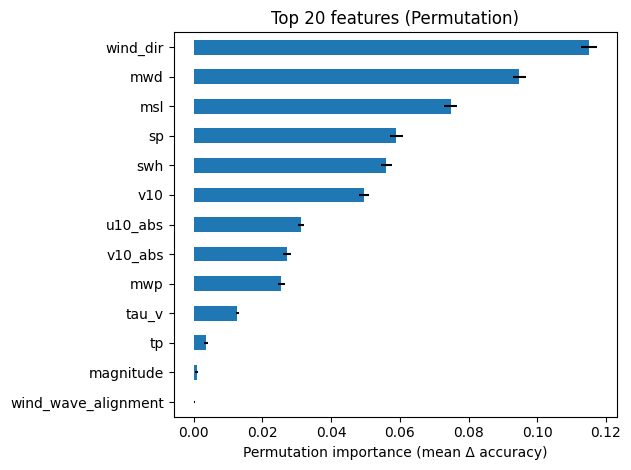


Top features (Permutation):
wind_dir               0.115086
mwd                    0.094808
msl                    0.074741
sp                     0.058994
swh                    0.056034
v10                    0.049464
u10_abs                0.031255
v10_abs                0.027213
mwp                    0.025469
tau_v                  0.012720
tp                     0.003467
magnitude              0.000833
wind_wave_alignment    0.000134
dtype: float64


In [17]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# ---------------------------
# 1) Build X, y (your logic)
# ---------------------------
drop_cols = {"station", "cluster"}

forbidden_substrings = ("sea_level","residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed")

forbidden_cols = {
    c for c in weathercluster_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

X = weathercluster_df.drop(columns=[c for c in cols_to_drop if c in weathercluster_df.columns])
y = weathercluster_df["cluster"]

# Keep only numeric features (RF can’t take strings unless encoded)
X = X.select_dtypes(include="number").copy()

# Optional: handle inf/nan if present
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# ---------------------------
# 2) Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# ---------------------------
# 3) Fit Random Forest
# ---------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=0,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

# ---------------------------
# 4) Basic evaluation
# ---------------------------
pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# ---------------------------
# 5) Feature importance (MDI / Gini)
# ---------------------------
mdi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

top_n = 20
plt.figure()
mdi.head(top_n).iloc[::-1].plot(kind="barh")
plt.xlabel("Random Forest feature importance (MDI)")
plt.title(f"Top {top_n} features (MDI/Gini)")
plt.tight_layout()
plt.show()

print("\nTop features (MDI):")
print(mdi.head(top_n))

# ---------------------------
# 6) Permutation importance (more reliable)
# ---------------------------
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1
)

perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=X.columns).loc[perm_imp.index]

plt.figure()
perm_imp.head(top_n).iloc[::-1].plot(kind="barh", xerr=perm_std.head(top_n).iloc[::-1].values)
plt.xlabel("Permutation importance (mean Δ accuracy)")
plt.title(f"Top {top_n} features (Permutation)")
plt.tight_layout()
plt.show()

print("\nTop features (Permutation):")
print(perm_imp.head(top_n))


Cluster structure is reproducible from independent features.

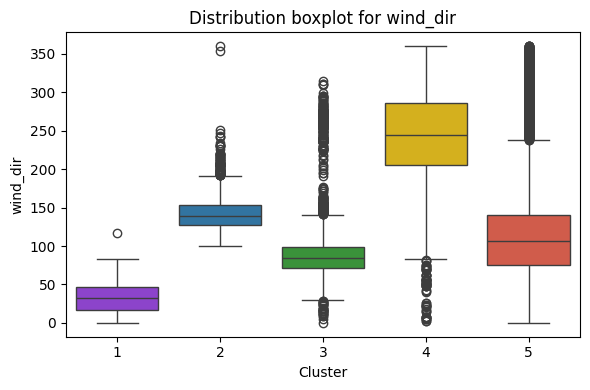

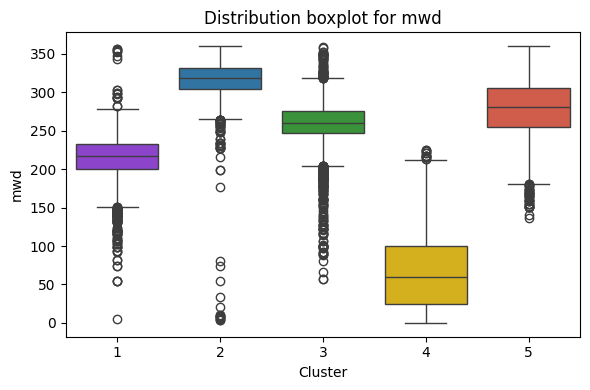

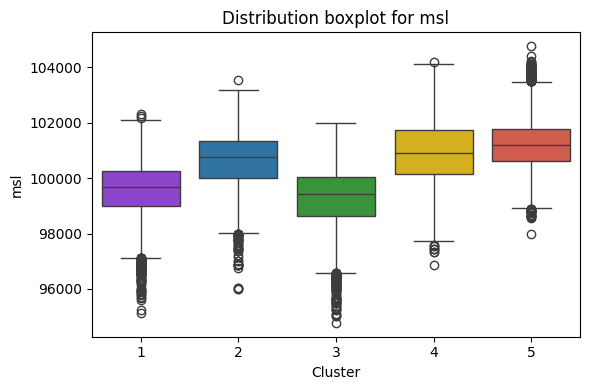

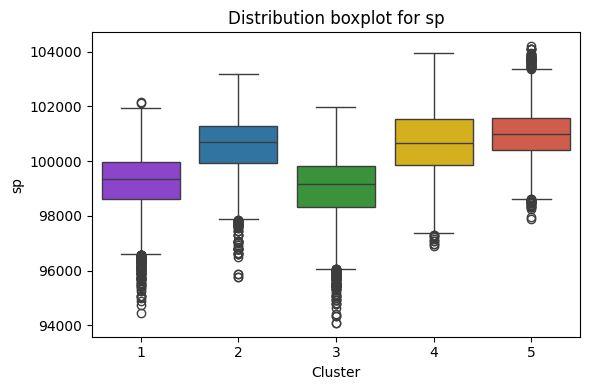

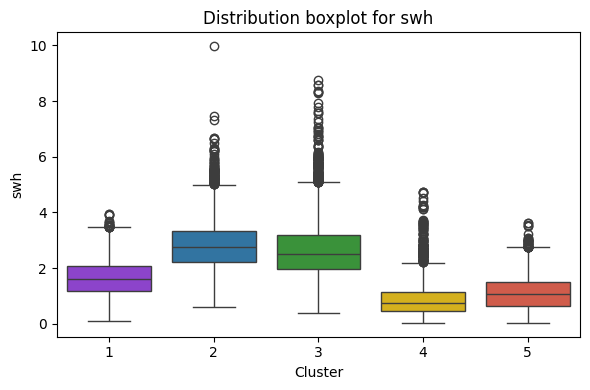

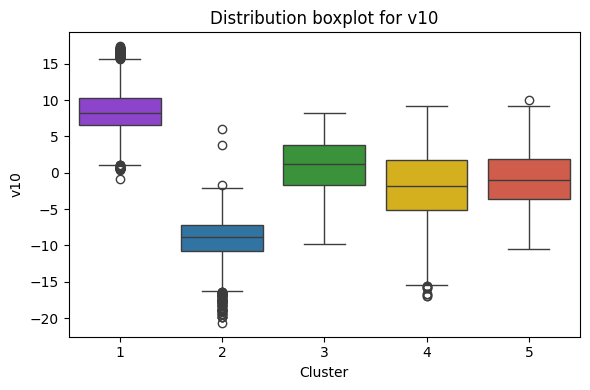

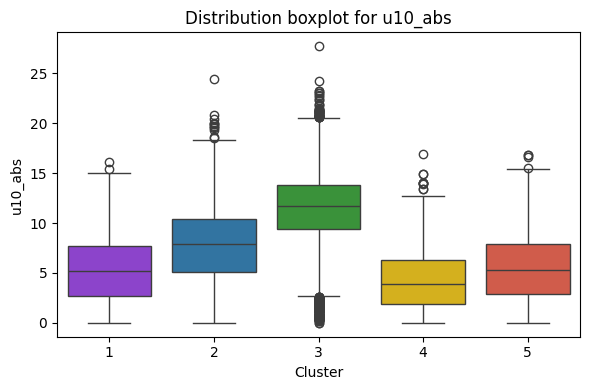

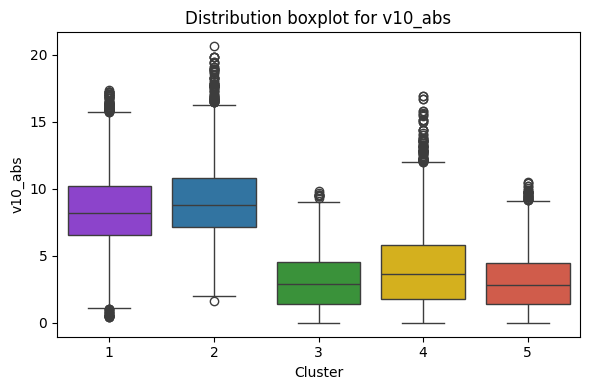

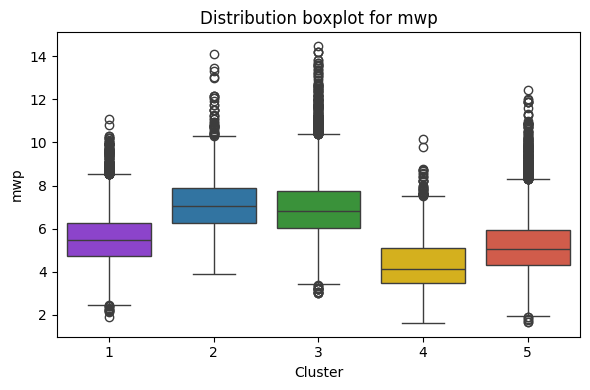

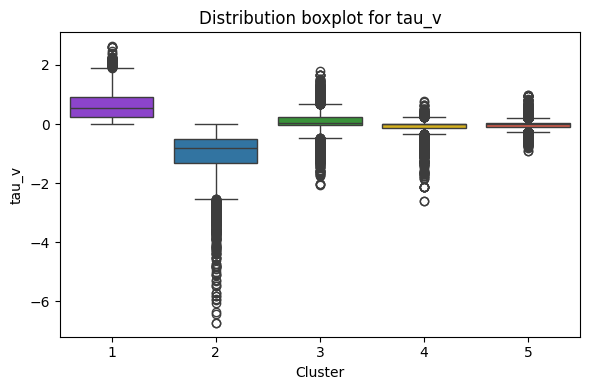

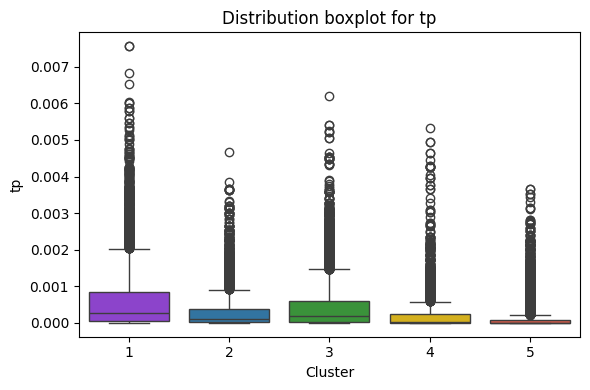

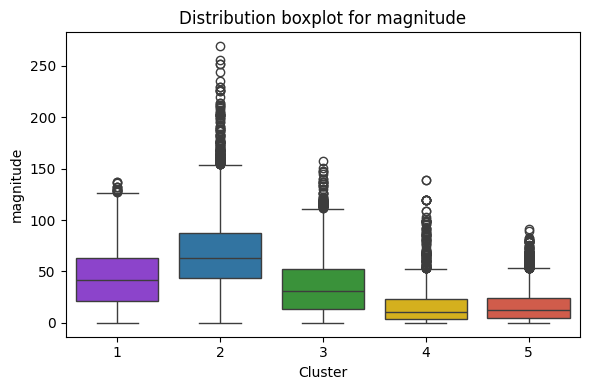

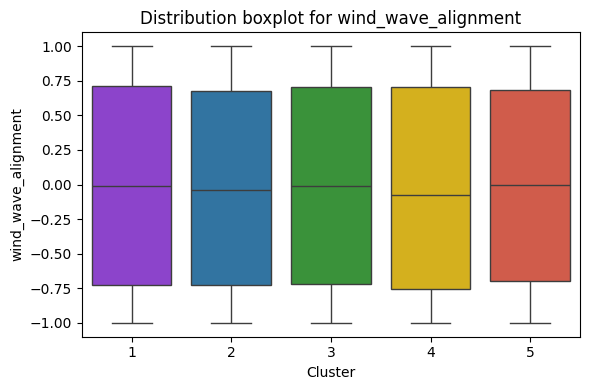

In [49]:
cluster_col = "cluster"
import seaborn as sns

weathercluster_df = weathercluster_df.copy()
weathercluster_df[cluster_col] = weathercluster_df[cluster_col].astype(str)

# Explicit numeric ordering
cluster_order = sorted(weathercluster_df[cluster_col].unique())
n_clusters = len(cluster_order)
top_feats = perm_imp.head(20).index

base_colors = ["#8E2DE2", "#1F77B4", "#2CA02C", "#F2C300", "#E64B35"]
palette = dict(zip(cluster_order, base_colors[:n_clusters]))
for f in top_feats:
     plt.figure(figsize=(6,4))
     sns.boxplot(data=weathercluster_df, x=cluster_col, y=f, hue=cluster_col, palette=palette, dodge=False, order=cluster_order)
     plt.legend([],[], frameon=False)
     plt.title(f"Distribution boxplot for {f}")
     plt.xlabel("Cluster")
     plt.tight_layout()
     plt.show()

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


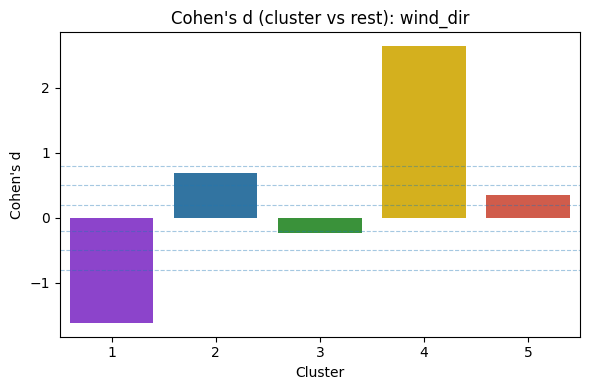

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


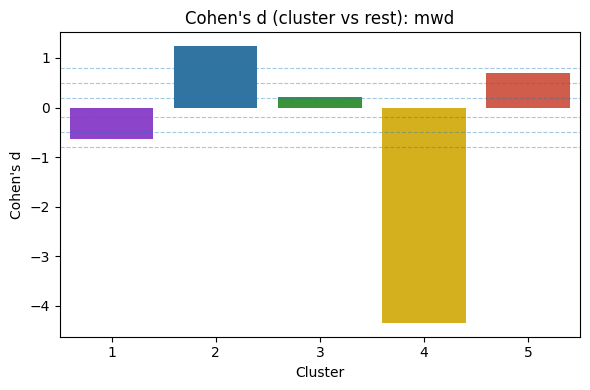

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


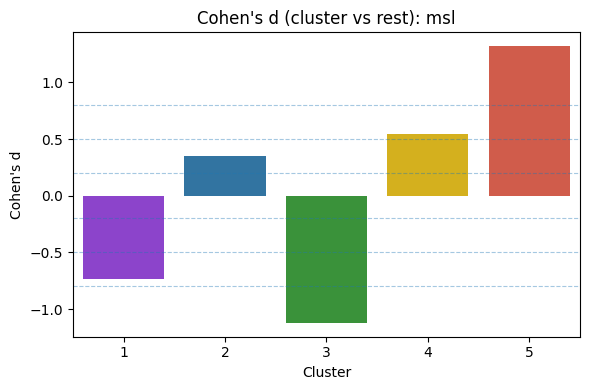

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


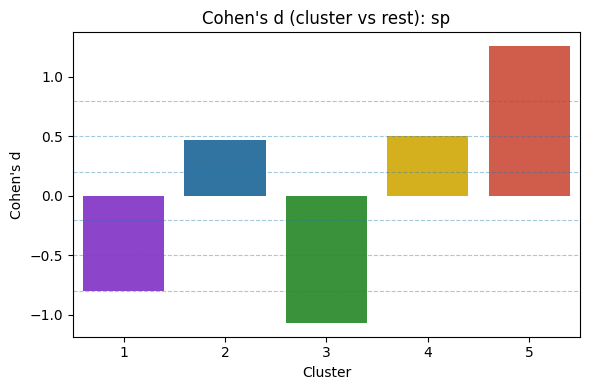

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


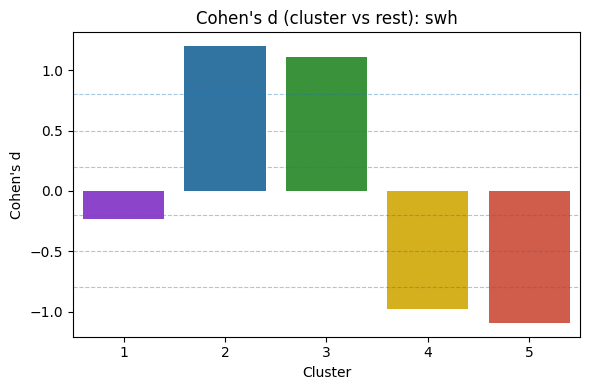

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


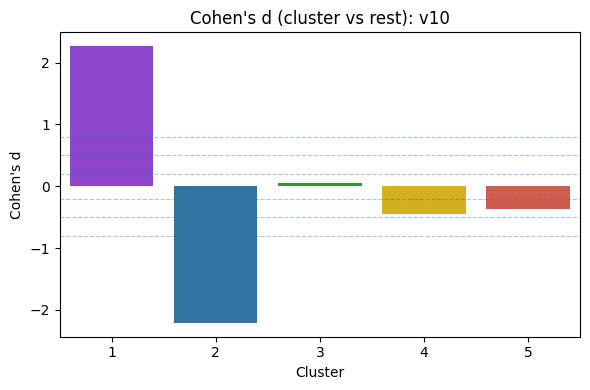

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


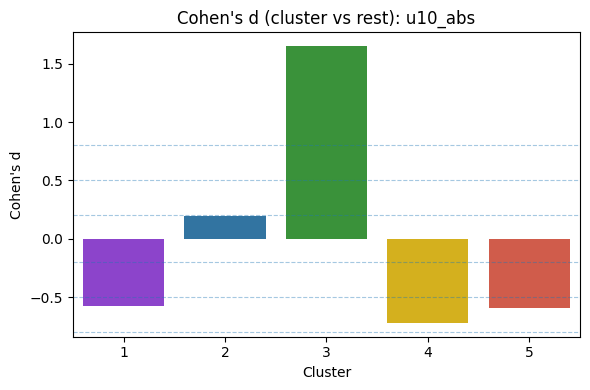

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


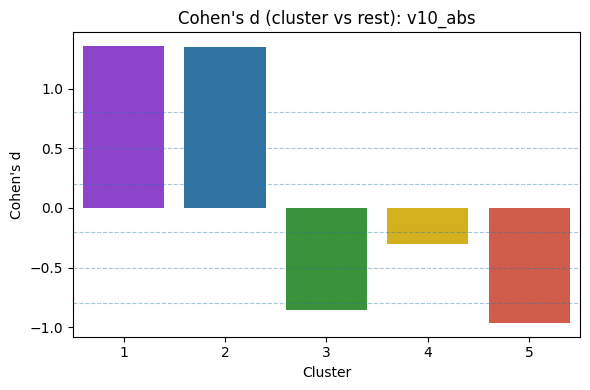

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


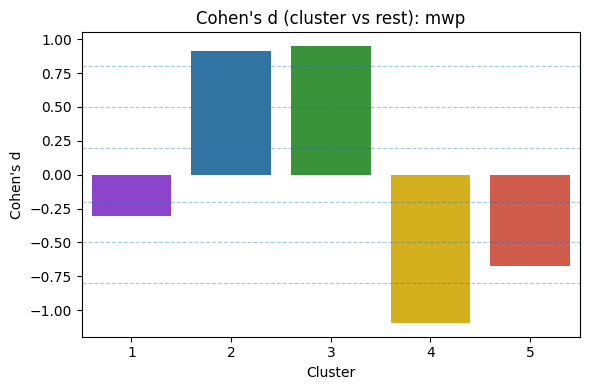

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


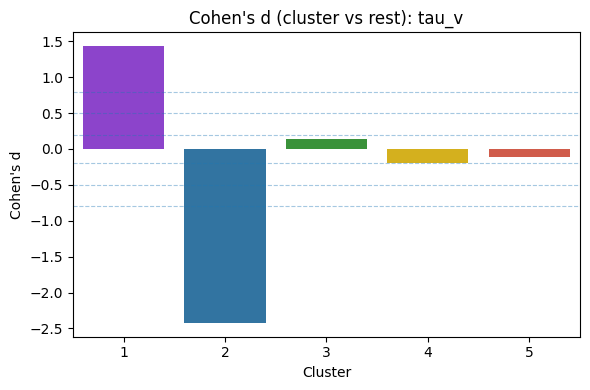

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


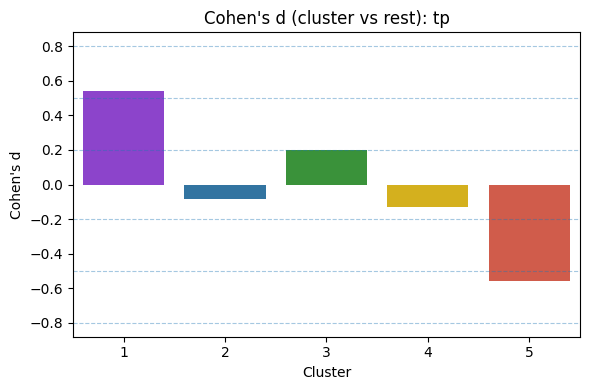

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


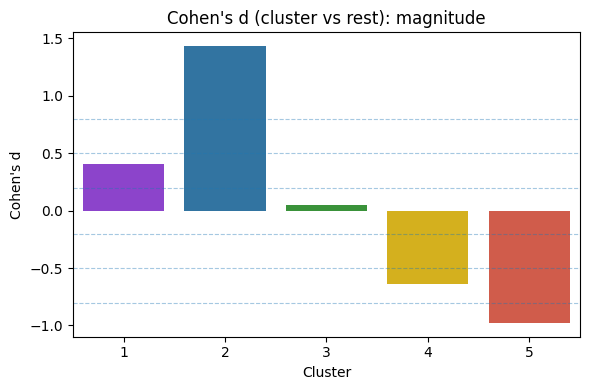

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1102021459.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


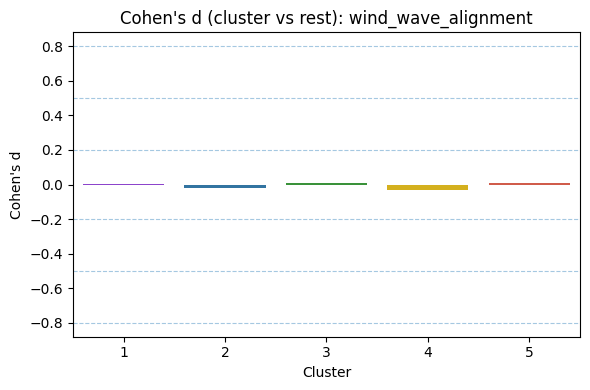

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cluster_col = "cluster"

df = weathercluster_df.copy()
df[cluster_col] = df[cluster_col].astype(str)

# Use your explicit order (numeric order even though strings)
cluster_order = sorted(df[cluster_col].unique(), key=lambda x: int(x) if x.isdigit() else x)
n_clusters = len(cluster_order)

base_colors = ["#8E2DE2", "#1F77B4", "#2CA02C", "#F2C300", "#E64B35"]
# If you ever have >5 clusters, fall back to a seaborn palette
if n_clusters > len(base_colors):
    palette_list = sns.color_palette("tab20", n_clusters)
    palette = dict(zip(cluster_order, palette_list))
else:
    palette = dict(zip(cluster_order, base_colors[:n_clusters]))

top_feats = perm_imp.head(20).index

def cohens_d(a, b):
    """Cohen's d for two independent samples (pooled SD)."""
    a = pd.Series(a).dropna().astype(float).to_numpy()
    b = pd.Series(b).dropna().astype(float).to_numpy()
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan

    s1 = np.std(a, ddof=1)
    s2 = np.std(b, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if sp == 0 or np.isnan(sp):
        return np.nan
    return (np.mean(a) - np.mean(b)) / sp

for f in top_feats:
    # Compute d for each cluster vs rest
    rows = []
    for c in cluster_order:
        in_c = df.loc[df[cluster_col] == c, f]
        out_c = df.loc[df[cluster_col] != c, f]
        d = cohens_d(in_c, out_c)
        rows.append({"cluster": c, "cohens_d": d, "abs_d": np.abs(d)})

    ddf = pd.DataFrame(rows)

    plt.figure(figsize=(6,4))
    ax = sns.barplot(
        data=ddf,
        x="cluster",
        y="cohens_d",
        order=cluster_order,
        palette=palette
    )

    # Reference lines (common effect size heuristics)
    for yline in [0.2, 0.5, 0.8, -0.2, -0.5, -0.8]:
        plt.axhline(yline, linestyle="--", linewidth=0.8, alpha=0.4)

    plt.title(f"Cohen's d (cluster vs rest): {f}")
    plt.xlabel("Cluster")
    plt.ylabel("Cohen's d")
    plt.tight_layout()
    plt.show()

In [51]:
import numpy as np
import pandas as pd
from itertools import combinations

def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan

    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na - 1)*sa + (nb - 1)*sb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled
features = ['wind_wave_alignment', 'lat', 'tp', 'lon',
       'mwd', 'mwp', 'wind_dir', 'v10_abs', 'tau_v', 'msl', 'sp', 'v10',
       'u10_abs', 'swh', "magnitude"]
clusters = sorted(weathercluster_df["cluster"].unique())

rows = []
for feat in features:
    for c1, c2 in combinations(clusters, 2):
        a = weathercluster_df.loc[weathercluster_df.cluster == c1, feat]
        b = weathercluster_df.loc[weathercluster_df.cluster == c2, feat]
        d = cohens_d(a, b)
        rows.append({
            "feature": feat,
            "cluster_1": c1,
            "cluster_2": c2,
            "cohens_d": d,
            "abs_d": abs(d)
        })

d_all = (
    pd.DataFrame(rows)
      .sort_values(["feature", "abs_d"], ascending=[True, False])
)

d_all


,feature,cluster_1,cluster_2,cohens_d,abs_d
36,lat,3,4,0.309097,0.309097
38,lat,3,6,0.298388,0.298388
23,lat,0,3,-0.258857,0.258857
28,lat,1,3,-0.231437,0.231437
33,lat,2,4,0.226695,0.226695
...,...,...,...,...,...
10,wind_wave_alignment,1,6,-0.003406,0.003406
7,wind_wave_alignment,1,3,-0.002998,0.002998
2,wind_wave_alignment,0,3,0.002046,0.002046
5,wind_wave_alignment,0,6,0.001693,0.001693


# unequal group sizes
mean / sqrt (std1^2+std2^2)

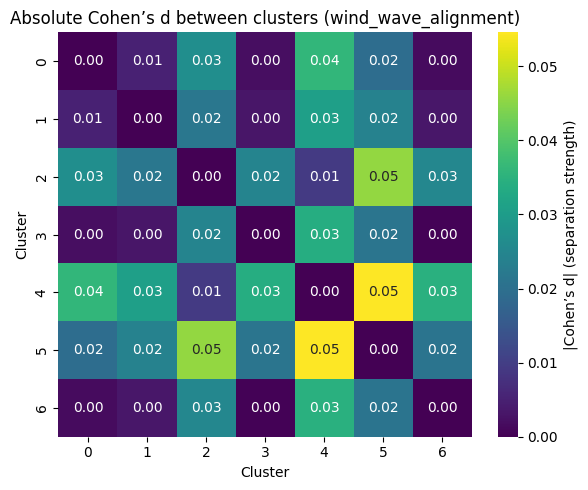

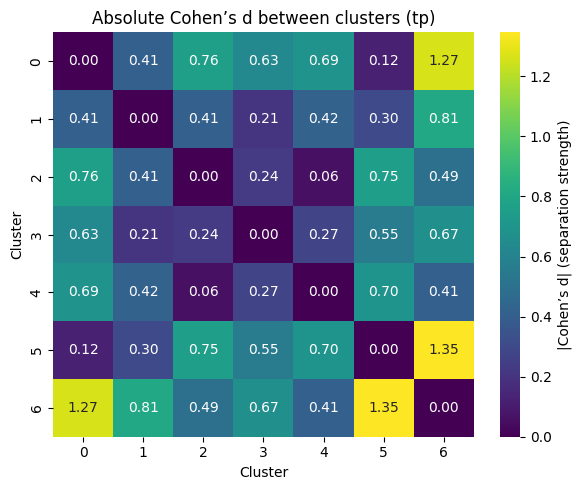

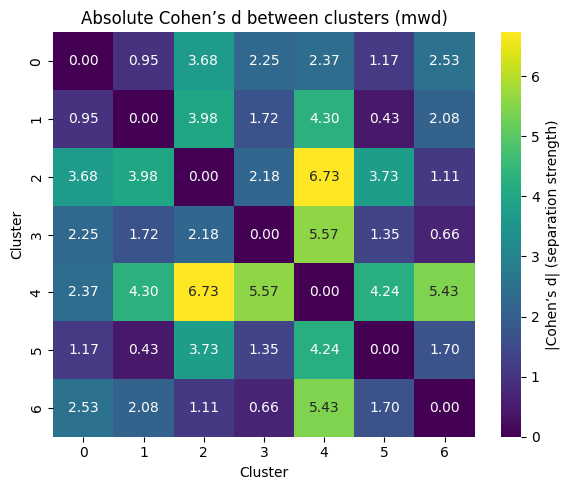

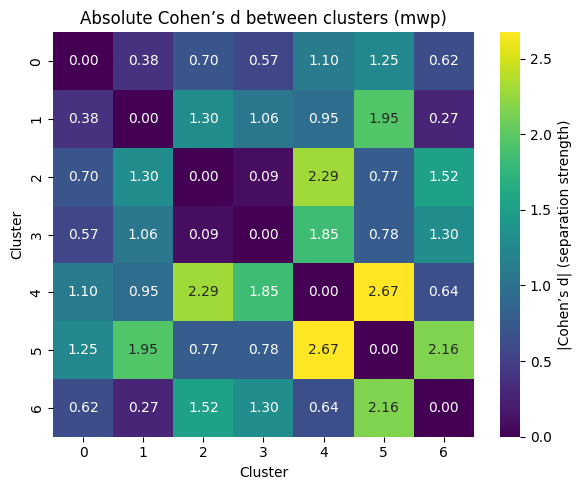

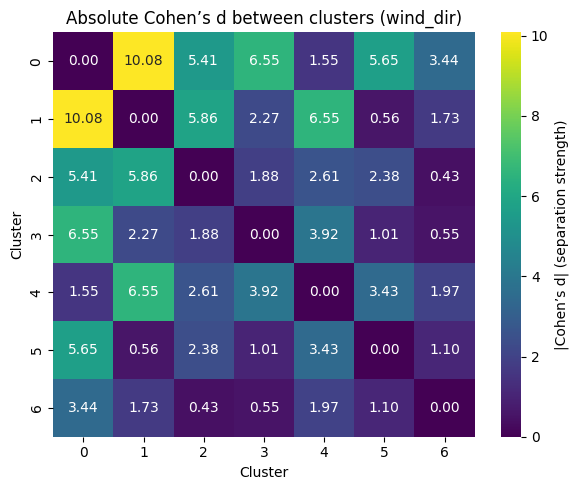

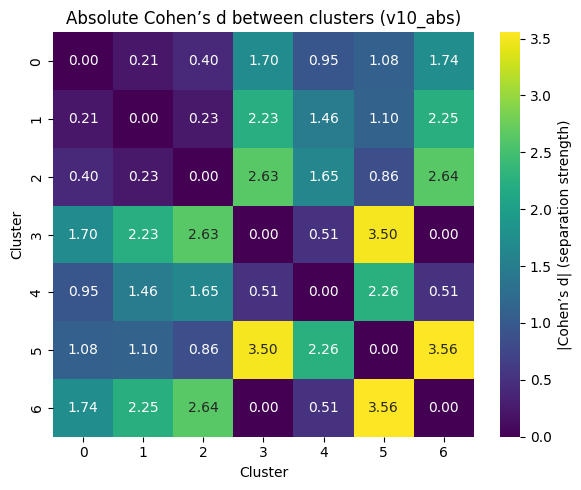

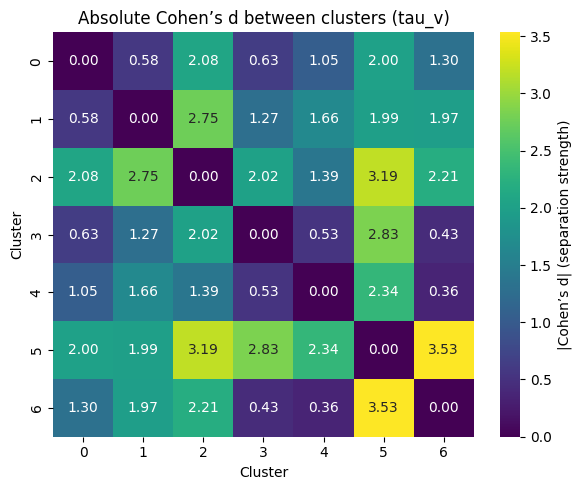

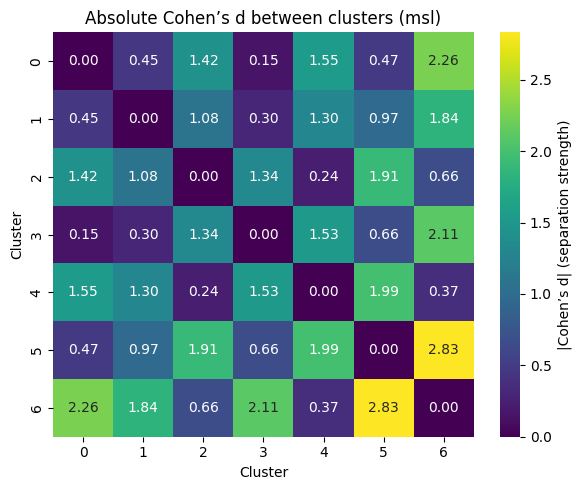

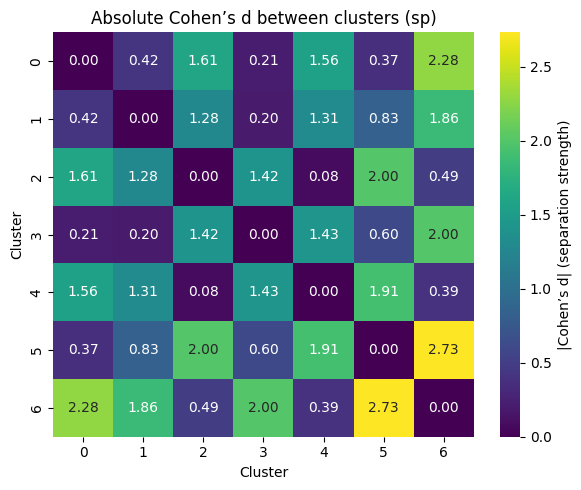

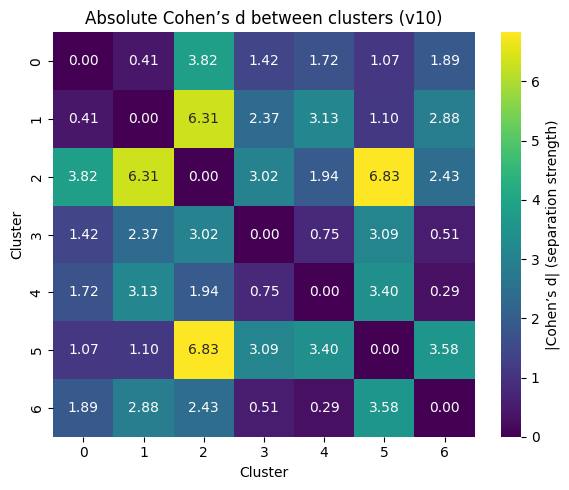

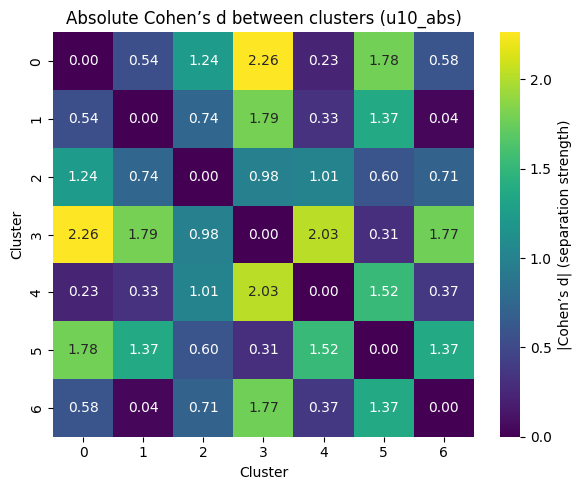

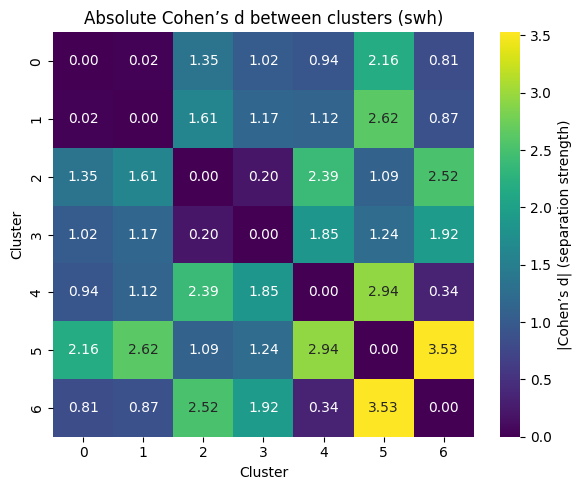

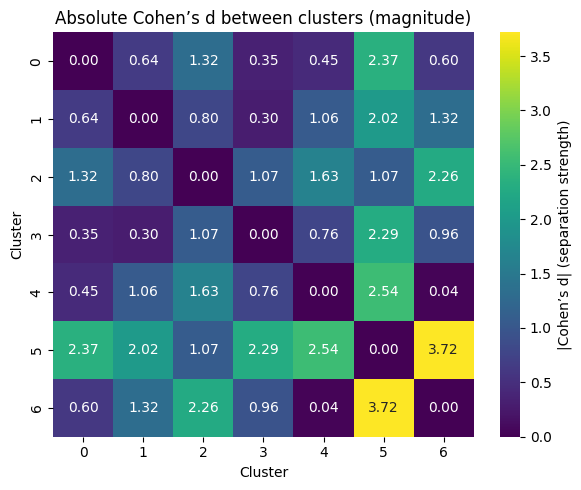

In [42]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan

    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na - 1)*sa + (nb - 1)*sb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled


def cohens_d_abs_matrix(df, feature):
    clusters = sorted(df["cluster"].unique())
    mat = pd.DataFrame(index=clusters, columns=clusters, dtype=float)

    for i in clusters:
        for j in clusters:
            if i == j:
                mat.loc[i, j] = 0.0
            else:
                a = df.loc[df.cluster == i, feature]
                b = df.loc[df.cluster == j, feature]
                mat.loc[i, j] = abs(cohens_d(a, b))
    return mat

features = ['wind_wave_alignment', 'tp',
       'mwd', 'mwp', 'wind_dir', 'v10_abs', 'tau_v', 'msl', 'sp', 'v10',
       'u10_abs', 'swh', "magnitude"]

for feat in features:
    mat = cohens_d_abs_matrix(weathercluster_df, feat)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        mat,
        cmap="viridis",          # sequential colormap
        vmin=0,
        vmax=np.nanmax(mat.values),
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "|Cohen’s d| (separation strength)"}
    )
    plt.title(f"Absolute Cohen’s d between clusters ({feat})")
    plt.xlabel("Cluster")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

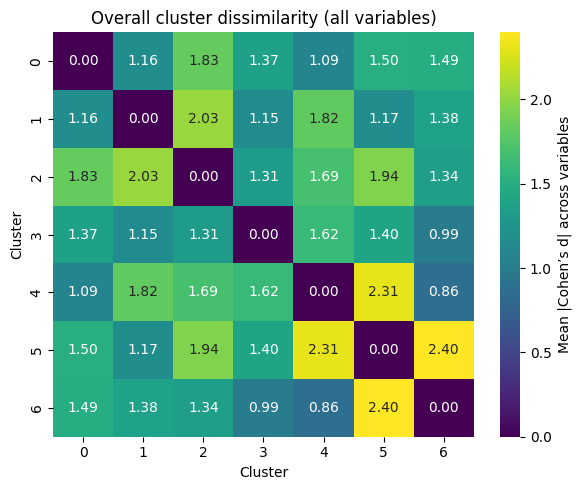

In [43]:
import numpy as np
import pandas as pd

clusters = sorted(weathercluster_df.cluster.unique())

# initialize accumulator
overall = pd.DataFrame(
    0.0, index=clusters, columns=clusters
)

for feat in features:
    mat = cohens_d_abs_matrix(weathercluster_df, feat)
    overall += mat

overall /= len(features)
plt.figure(figsize=(6, 5))
sns.heatmap(
    overall,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Mean |Cohen’s d| across variables"}
)
plt.title("Overall cluster dissimilarity (all variables)")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


In [ ]:
records = []

for i in clusters:
    for j in clusters:
        if i >= j:
            continue

        ds = {}
        for feat in features:
            mat = cohens_d_abs_matrix(weathercluster_df, feat)
            ds[feat] = mat.loc[i, j]

        top_feat = max(ds, key=ds.get)

        records.append({
            "cluster_i": i,
            "cluster_j": j,
            "mean_abs_d": np.mean(list(ds.values())),
            "max_abs_d": ds[top_feat],
            "driving_variable": top_feat
        })

pairwise_summary = pd.DataFrame(records)


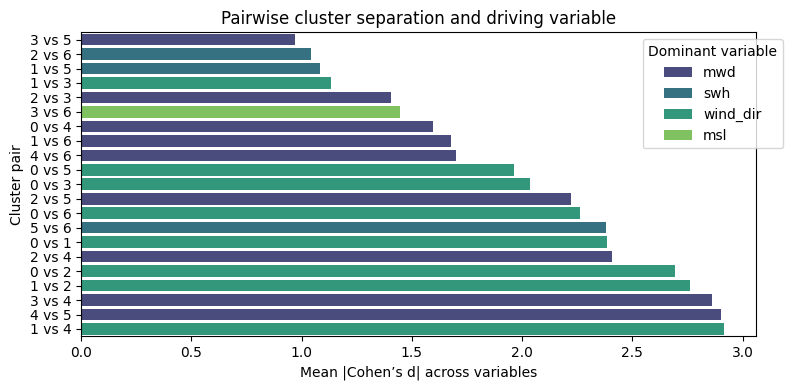

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=pairwise_summary.sort_values("mean_abs_d"),
    x="mean_abs_d",
    y=pairwise_summary.sort_values("mean_abs_d")
        .apply(lambda r: f"{r.cluster_i} vs {r.cluster_j}", axis=1),
    hue="driving_variable",
    dodge=False,
    palette="viridis"
)

plt.xlabel("Mean |Cohen’s d| across variables")
plt.ylabel("Cluster pair")
plt.title("Pairwise cluster separation and driving variable")
plt.legend(title="Dominant variable", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def mean_abs_cohens_d_vs_others(df, feature, cluster_id):
    """Mean |Cohen's d| of cluster vs all other clusters"""
    target = df.loc[df.cluster == cluster_id, feature]
    ds = []

    for other in df.cluster.unique():
        if other == cluster_id:
            continue
        comp = df.loc[df.cluster == other, feature]
        d = cohens_d(target, comp)
        if np.isfinite(d):
            ds.append(abs(d))

    return np.mean(ds) if ds else np.nan


In [ ]:
features = ["swh", "mwd", "sp", "msl", "wind_dir"]
clusters = sorted(weathercluster_df.cluster.unique())

rows = []

for c in clusters:
    for f in features:
        rows.append({
            "cluster": c,
            "feature": f,
            "mean_abs_d": mean_abs_cohens_d_vs_others(
                weathercluster_df, f, c
            )
        })

sep_df = pd.DataFrame(rows)

top2_df = (
    sep_df
    .sort_values(["cluster", "mean_abs_d"], ascending=[True, False])
    .groupby("cluster")
    .head(2)
)


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_62351/766518768.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


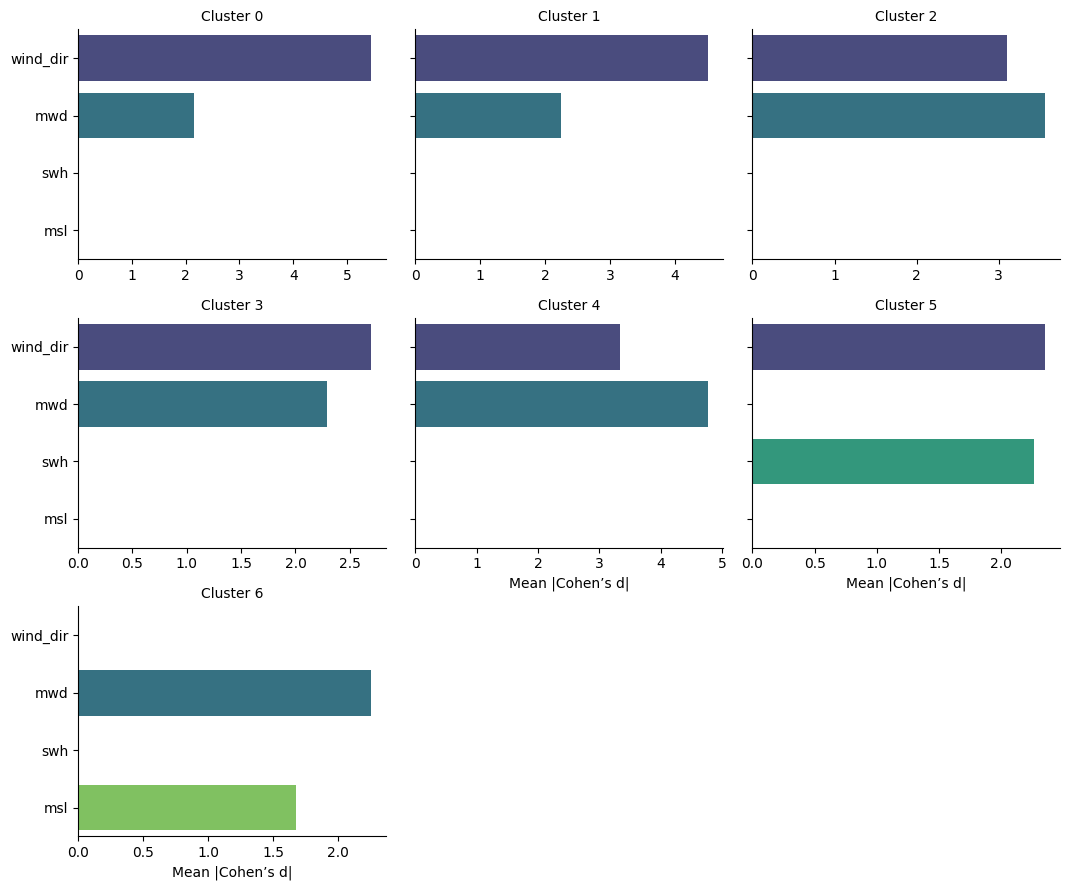

In [ ]:
g = sns.catplot(
    data=top2_df,
    kind="bar",
    x="mean_abs_d",
    y="feature",
    col="cluster",
    col_wrap=3,
    sharex=False,
    height=3,
    aspect=1.2,
    palette="viridis"
)

g.set_titles("Cluster {col_name}")
g.set_xlabels("Mean |Cohen’s d|")
g.set_ylabels("")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def cohens_d_cluster_vs_rest(df, feature, cluster_id):
    a = df.loc[df.cluster == cluster_id, feature]
    b = df.loc[df.cluster != cluster_id, feature]
    return abs(cohens_d(a, b))


In [ ]:
features = ["swh", "mwd", "sp", "msl", "wind_dir"]
clusters = sorted(weathercluster_df.cluster.unique())

rows = []

for c in clusters:
    for f in features:
        rows.append({
            "cluster": c,
            "feature": f,
            "abs_d": cohens_d_cluster_vs_rest(
                weathercluster_df, f, c
            )
        })

sep_df = pd.DataFrame(rows)


In [ ]:
top2_df = (
    sep_df
    .sort_values(["cluster", "abs_d"], ascending=[True, False])
    .groupby("cluster")
    .head(2)
)


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_62351/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


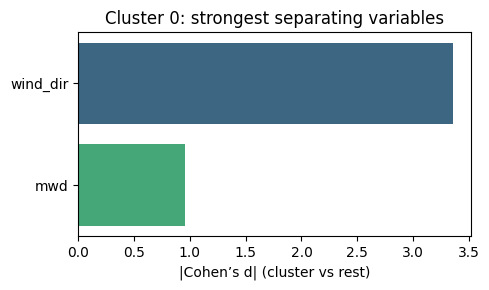

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_62351/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


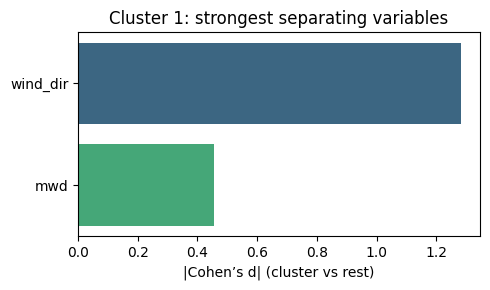

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_62351/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


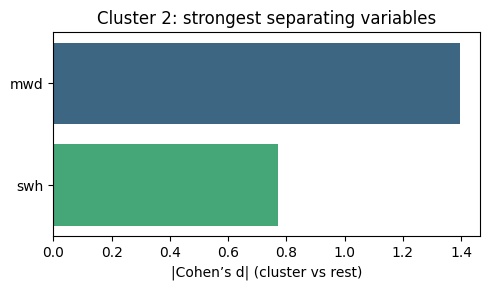

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_62351/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


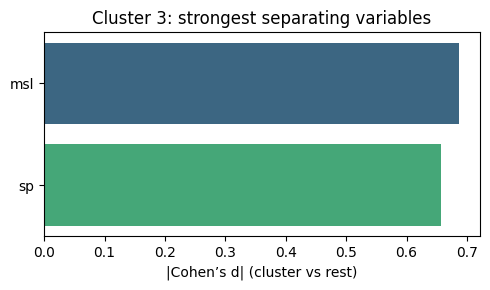

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_62351/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


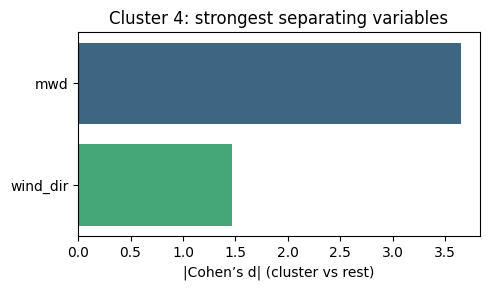

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_62351/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


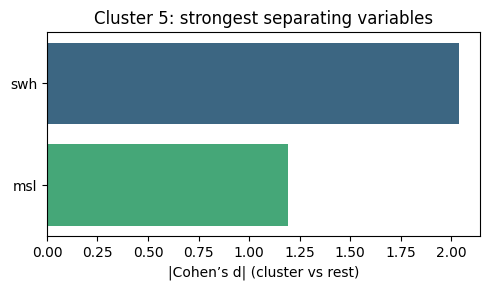

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_62351/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


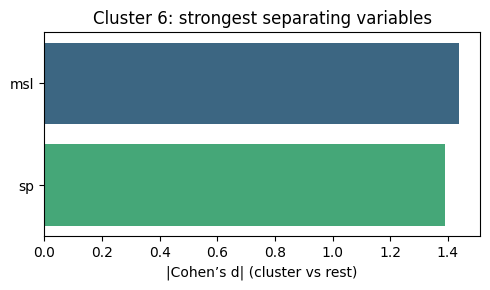

In [ ]:
for c in clusters:
    sub = top2_df[top2_df.cluster == c]

    plt.figure(figsize=(5, 3))
    sns.barplot(
        data=sub,
        x="abs_d",
        y="feature",
        palette="viridis"
    )

    plt.title(f"Cluster {c}: strongest separating variables")
    plt.xlabel("|Cohen’s d| (cluster vs rest)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


Interpretation

|d| ≈ 0.2 → small

|d| ≈ 0.5 → medium

|d| ≥ 0.8 → large separation

|d| ≥ 1.2 → very strong

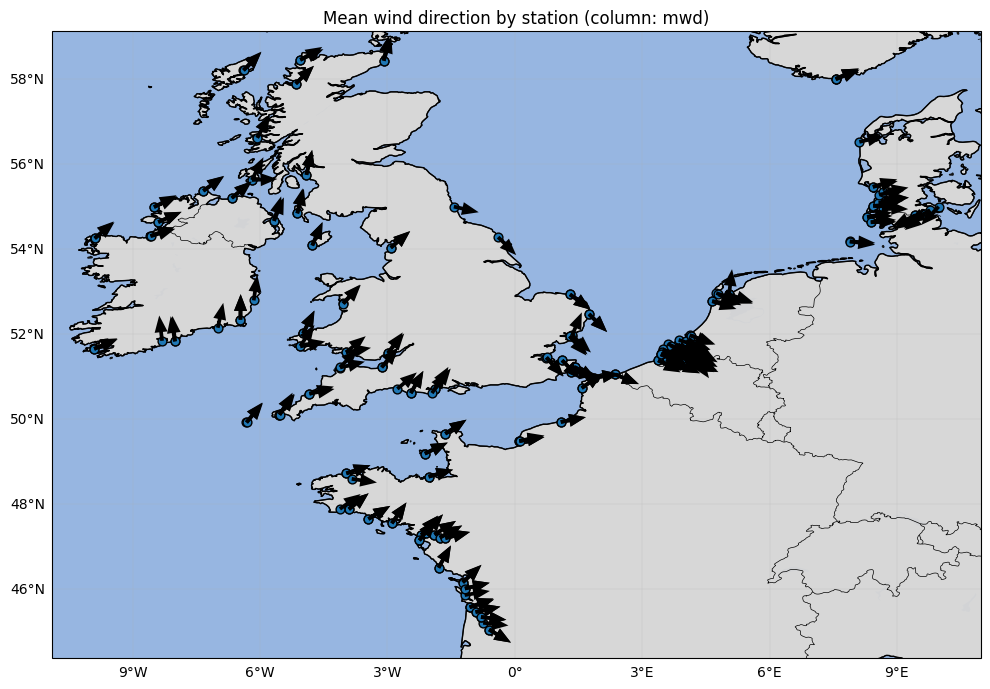

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Inputs you may need to adjust ----
df = weathercluster_df.copy()

# Required columns: station + lat/lon
req = {"station", "lat", "lon"}
assert req.issubset(df.columns), f"weather_cluster_df must include {req}"

# Try to auto-detect a wind-direction column (degrees)
cand_cols = [c for c in df.columns if any(s in c.lower() for s in ["wind_dir", "winddirection", "wd", "wdir", "dir"])]
if not cand_cols:
    raise ValueError("Couldn't auto-detect wind direction column. Set wind_dir_col manually.")
wind_dir_col = cand_cols[0]   # <-- or set manually, e.g. wind_dir_col = "wind_dir"

# If your wind direction is in radians, convert it before proceeding.
# df[wind_dir_col] = np.rad2deg(df[wind_dir_col])

# ---- Clean numeric ----
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df[wind_dir_col] = pd.to_numeric(df[wind_dir_col], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["station","lon","lat",wind_dir_col])

# ---- Circular mean per station (degrees) ----
# Assumption: wind direction is METEOROLOGICAL degrees (0=N, 90=E) and indicates "FROM" direction.
# We'll plot arrows pointing TO where wind is going (common for vector arrows).
theta_from = df[wind_dir_col].values % 360.0
theta_to = (theta_from + 180.0) % 360.0

# Circular mean: mean of unit vectors (using "TO" direction)
rad = np.deg2rad(theta_to)
df["_sin"] = np.sin(rad)
df["_cos"] = np.cos(rad)

station_mean = (
    df.groupby("station", as_index=False)
      .agg(lon=("lon","mean"),
           lat=("lat","mean"),
           sin_mean=("_sin","mean"),
           cos_mean=("_cos","mean"))
)

# Mean direction (TO), in degrees meteorological
mean_rad = np.arctan2(station_mean["sin_mean"].values, station_mean["cos_mean"].values)
mean_deg_to = (np.rad2deg(mean_rad) + 360.0) % 360.0
station_mean["mean_wind_dir_to_deg"] = mean_deg_to

# Convert MET degrees (0=N, clockwise) -> plotting components (x=lon/east, y=lat/north)
# MET "TO" degrees: 0=N means arrow points +y. 90=E means +x.
theta = np.deg2rad(station_mean["mean_wind_dir_to_deg"].values)
u = np.sin(theta)   # east component
v = np.cos(theta)   # north component

# ---- Map ----
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

lon_min, lon_max = station_mean["lon"].min(), station_mean["lon"].max()
lat_min, lat_max = station_mean["lat"].min(), station_mean["lat"].max()
pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent([lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat], crs=proj)

ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", alpha=0.9, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Plot station points
ax.scatter(station_mean["lon"], station_mean["lat"], s=40, transform=proj, zorder=10, edgecolors="k")

# Quiver: constant-length arrows; scale_units='xy' keeps units consistent
# Increase/decrease 'arrow_len' to taste.
arrow_len = 0.6
ax.quiver(
    station_mean["lon"].values,
    station_mean["lat"].values,
    u * arrow_len,
    v * arrow_len,
    transform=proj,
    zorder=20,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    headwidth=3.5,
    headlength=4.5
)

ax.set_title(f"Mean wind direction by station (column: {wind_dir_col})")
plt.tight_layout()
plt.show()


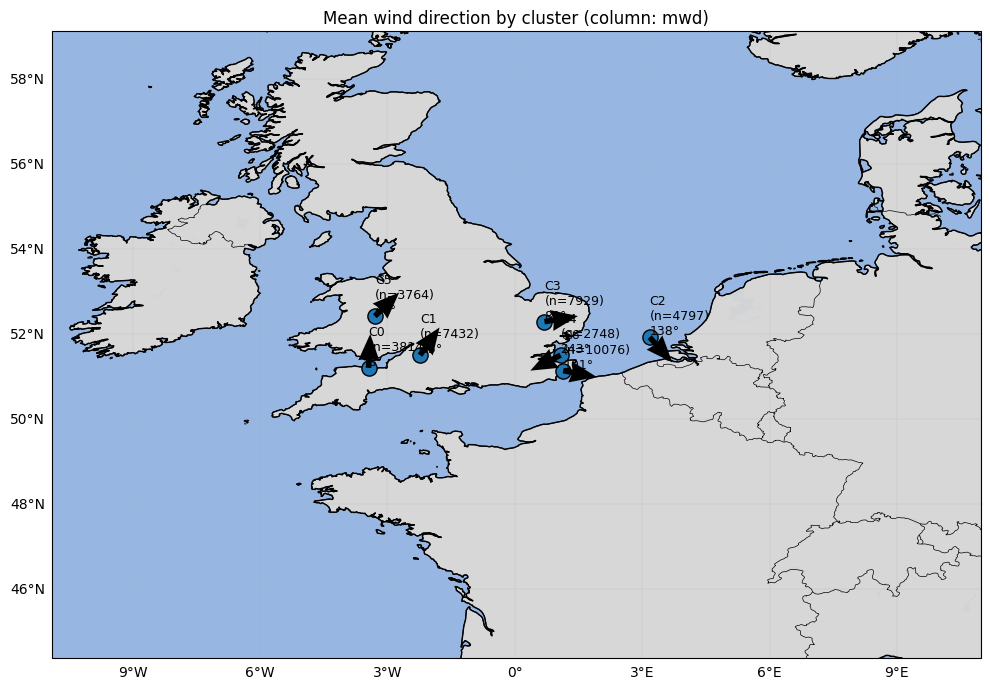

   cluster      n        lat       lon  mean_wind_dir_to_deg
0        0   3814  51.202897 -3.441491              2.807834
1        1   7432  51.501537 -2.231463             35.288294
2        2   4797  51.925020  3.177119            138.032444
3        3   7929  52.289915  0.699925             80.417128
4        4   2748  51.503145  1.079873            242.800809
5        5   3764  52.420113 -3.293603             45.744096
6        6  10076  51.137896  1.142382            100.686115


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df = weathercluster_df.copy()

# --- Required columns ---
req = {"cluster", "lat", "lon"}
assert req.issubset(df.columns), f"weathercluster_df must include {req}"

# --- Auto-detect wind direction column (degrees) ---
cand_cols = [c for c in df.columns if any(s in c.lower() for s in ["wind_dir", "winddirection", "wd", "wdir", "dir"])]
if not cand_cols:
    raise ValueError("Couldn't auto-detect wind direction column. Set wind_dir_col manually.")
wind_dir_col = cand_cols[0]  # or set explicitly

# --- Clean numeric ---
for c in ["lon", "lat", "cluster", wind_dir_col]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["lon", "lat", "cluster", wind_dir_col])

# --- Circular mean per cluster (meteorological degrees; assumed 'FROM') ---
theta_from = df[wind_dir_col].values % 360.0
theta_to = (theta_from + 180.0) % 360.0  # plot arrows pointing where wind goes

rad = np.deg2rad(theta_to)
df["_sin"] = np.sin(rad)
df["_cos"] = np.cos(rad)

cluster_mean = (
    df.groupby("cluster", as_index=False)
      .agg(lon=("lon", "mean"),
           lat=("lat", "mean"),
           sin_mean=("_sin", "mean"),
           cos_mean=("_cos", "mean"),
           n=("cluster", "size"))
)

mean_rad = np.arctan2(cluster_mean["sin_mean"].values, cluster_mean["cos_mean"].values)
mean_deg_to = (np.rad2deg(mean_rad) + 360.0) % 360.0
cluster_mean["mean_wind_dir_to_deg"] = mean_deg_to

# Components for plotting (MET degrees: 0=N, 90=E)
theta = np.deg2rad(cluster_mean["mean_wind_dir_to_deg"].values)
u = np.sin(theta)   # east
v = np.cos(theta)   # north

# --- Map ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

lon_min, lon_max = df["lon"].min(), df["lon"].max()
lat_min, lat_max = df["lat"].min(), df["lat"].max()
pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent([lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat], crs=proj)

ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", alpha=0.9, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Cluster centroid points
ax.scatter(cluster_mean["lon"], cluster_mean["lat"], s=120, transform=proj, zorder=10, edgecolors="k")

# Cluster mean direction arrows
arrow_len = 0.8
ax.quiver(
    cluster_mean["lon"].values,
    cluster_mean["lat"].values,
    u * arrow_len,
    v * arrow_len,
    transform=proj,
    zorder=20,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.006,
    headwidth=3.8,
    headlength=4.8
)

# Label clusters (optionally include n)
for _, r in cluster_mean.iterrows():
    ax.text(
        r["lon"], r["lat"],
        f"C{int(r['cluster'])}\n(n={int(r['n'])})\n{r['mean_wind_dir_to_deg']:.0f}°",
        transform=proj,
        ha="left", va="bottom",
        fontsize=9,
        zorder=30
    )

ax.set_title(f"Mean wind direction by cluster (column: {wind_dir_col})")
plt.tight_layout()
plt.show()

# Also print the table for inspection
display_cols = ["cluster", "n", "lat", "lon", "mean_wind_dir_to_deg"]
print(cluster_mean[display_cols].sort_values("cluster"))


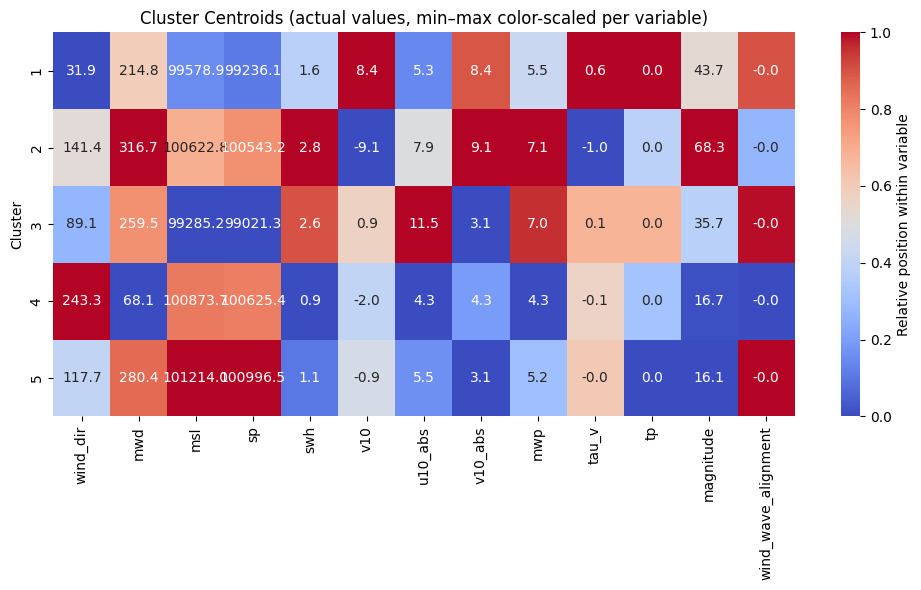

In [60]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cluster_means = weathercluster_df.groupby("cluster")[top_feats].mean()

# Column-wise min–max for coloring
color_data = (
    cluster_means - cluster_means.min()
) / (
    cluster_means.max() - cluster_means.min()
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    color_data,
    annot=cluster_means.round(1), 
    fmt="",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Relative position within variable"}
)
plt.title("Cluster Centroids (actual values, min–max color-scaled per variable)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


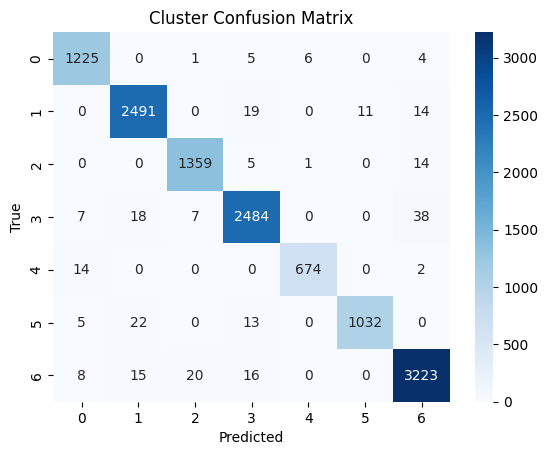

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Cluster Confusion Matrix")
plt.show()



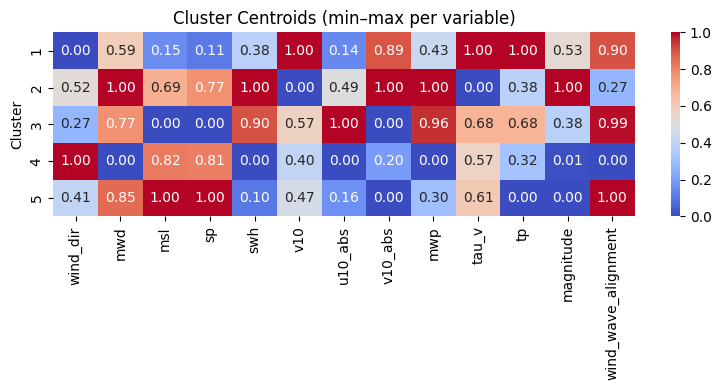

In [61]:
cluster_means_minmax = (
    cluster_means - cluster_means.min()
) / (
    cluster_means.max() - cluster_means.min()
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    cluster_means_minmax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)
plt.title("Cluster Centroids (min–max per variable)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1376493431.py:10: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


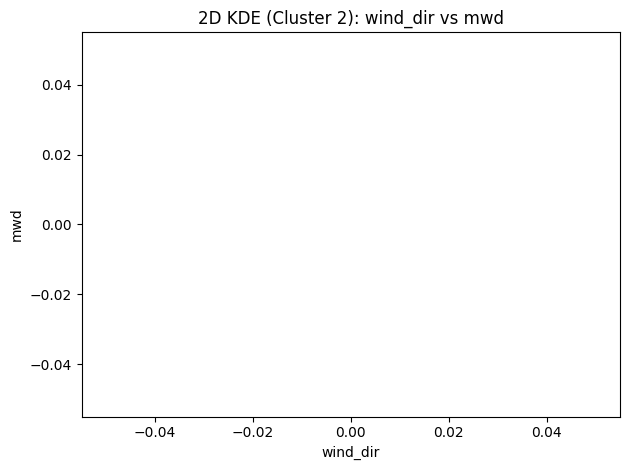

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_id = 2
feats2d = perm_imp.head(2).index  # or set: feats2d = ["featA", "featB"]

df5 = weathercluster_df.loc[weathercluster_df["cluster"] == cluster_id, feats2d].dropna()

plt.figure()
sns.kdeplot(
    data=df5,
    x=feats2d[0],
    y=feats2d[1],
    fill=True,
    levels=25,
    thresh=0.05
)
plt.title(f"2D KDE (Cluster {cluster_id}): {feats2d[0]} vs {feats2d[1]}")
plt.tight_layout()
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85193/1589926803.py:12: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


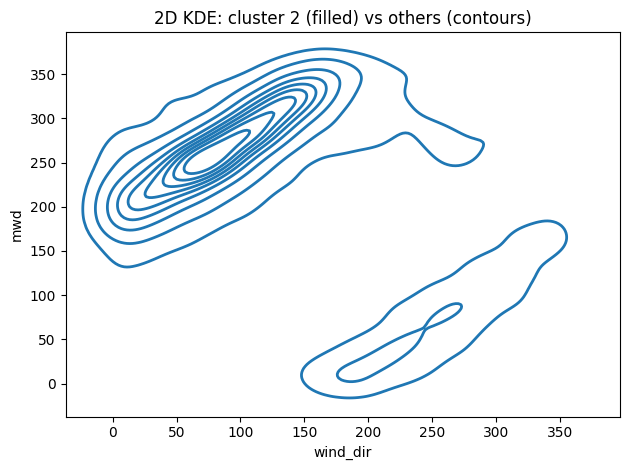

In [65]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cluster_id = 2
feats2d = perm_imp.head(2).index  # or choose your own

df = weathercluster_df.loc[:, ["cluster", *feats2d]].dropna()
df["is_cluster5"] = np.where(df["cluster"] == cluster_id, f"cluster {cluster_id}", "other clusters")

plt.figure()
sns.kdeplot(
    data=df[df["is_cluster5"] == f"cluster {cluster_id}"],
    x=feats2d[0], y=feats2d[1],
    fill=True, levels=25, thresh=0.05
)
sns.kdeplot(
    data=df[df["is_cluster5"] == "other clusters"],
    x=feats2d[0], y=feats2d[1],
    levels=10, linewidths=2
)
plt.title(f"2D KDE: cluster {cluster_id} (filled) vs others (contours)")
plt.tight_layout()
plt.show()
